In [65]:
cd ..

/home/veronika/Documents


In [71]:

import logging
import random
import pandas as pd
import random
import matplotlib.pylab as plt
import numpy as np

import os
import sys




logger = logging.getLogger(name=__name__)

### my own notebooks
import src.vertexModel2 as vertexModel2
import src.inputMechanicalParametersModel2 as MechanicalParams2
import src.auxFunctions as auxFunctions

import warnings
warnings.filterwarnings('ignore')


In [142]:
def collapse_single_edge(cellmap, geom, edge_id):
    """
    Collapses a single specified edge by merging its two vertices into one.
    The new vertex is placed at the midpoint of the original edge.
    
    Parameters:~
    -----------
    cellmap : object
        The cellmap containing vertex and edge DataFrames
    geom : object
        Geometry handler
    energyContributions_model : object
        Energy model for the system
    edge_id : int
        ID of the edge to collapse (must be an inside edge, not boundary)
    
    Returns:
    --------
    cellmap : object
        Updated cellmap after edge collapse
    """
    
    logger.info(f"Collapsing edge: {edge_id}")
    
    # Verify edge exists
    if edge_id not in cellmap.edge_df.index:
        raise ValueError(f"Edge {edge_id} not found in cellmap.edge_df")
    
    # --- STEP 1: Get the two vertices of the edge ---
    edge_row = cellmap.edge_df.loc[edge_id]
    v1 = edge_row['srce']
    v2 = edge_row['trgt']
    
    logger.info(f"Merging vertices {v1} and {v2}")
    
    # Verify both vertices exist
    if v1 not in cellmap.vert_df.index or v2 not in cellmap.vert_df.index:
        raise ValueError(f"Vertex {v1} or {v2} not found in cellmap.vert_df")
    
    # --- STEP 2: Calculate midpoint coordinates ---
    x1 = cellmap.vert_df.loc[v1, 'x']
    y1 = cellmap.vert_df.loc[v1, 'y']
    x2 = cellmap.vert_df.loc[v2, 'x']
    y2 = cellmap.vert_df.loc[v2, 'y']
    
    midpoint_x = (x1 + x2) / 2
    midpoint_y = (y1 + y2) / 2
    
    # --- STEP 3: Create new vertex at midpoint ---
    new_vertex_id = max(cellmap.vert_df.index) + 1 if not cellmap.vert_df.empty else 0
    new_vertex_data = cellmap.vert_df.loc[v1].copy()
    new_vertex_data['x'] = midpoint_x
    new_vertex_data['y'] = midpoint_y
    cellmap.vert_df.loc[new_vertex_id] = new_vertex_data
    
    # --- STEP 4: Rewire edges - replace v1 and v2 with new vertex ---
    cellmap.edge_df.loc[cellmap.edge_df["srce"] == v1, "srce"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["srce"] == v2, "srce"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["trgt"] == v1, "trgt"] = new_vertex_id
    cellmap.edge_df.loc[cellmap.edge_df["trgt"] == v2, "trgt"] = new_vertex_id
    
    # --- STEP 5: Delete the collapsed edge and its parallel edge ---
    parallel_edges = cellmap.edge_df[
        ((cellmap.edge_df["srce"] == v1) & (cellmap.edge_df["trgt"] == v2)) |
        ((cellmap.edge_df["srce"] == v2) & (cellmap.edge_df["trgt"] == v1))
    ].index.tolist()
    
    edges_to_delete = [edge_id] + parallel_edges
    cellmap.edge_df.drop(edges_to_delete, inplace=True, errors='ignore')
    
    # --- STEP 6: Delete old vertices ---
    cellmap.vert_df.drop([v1, v2], inplace=True, errors='ignore')
    
    # --- STEP 7: Remove self-loops ---
    cellmap.edge_df = cellmap.edge_df[cellmap.edge_df["srce"] != cellmap.edge_df["trgt"]]
    
    # --- STEP 8: Remove duplicate edges ---
    cellmap.edge_df = cellmap.edge_df.drop_duplicates(subset=['srce', 'trgt'])
    
    # --- STEP 9: Reset indices and update geometry ---
    cellmap.reset_index()
    
    # --- STEP 10: Update active vertices ---
    if hasattr(cellmap, 'active_verts'):
        cellmap.active_verts = list(cellmap.vert_df.index)
    
    geom.update_all(cellmap)

    new_vertex_id = cellmap.vert_df.index.max()


    
    return cellmap, new_vertex_id

In [143]:
# Initialize cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(20)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

#Change outside vertices mechanics
high_viscosity_value = 1000000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
#energyContributions_model.compute_energy(cellmap)
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 200)


Topology changed!


Highlighting edge: 400 in red


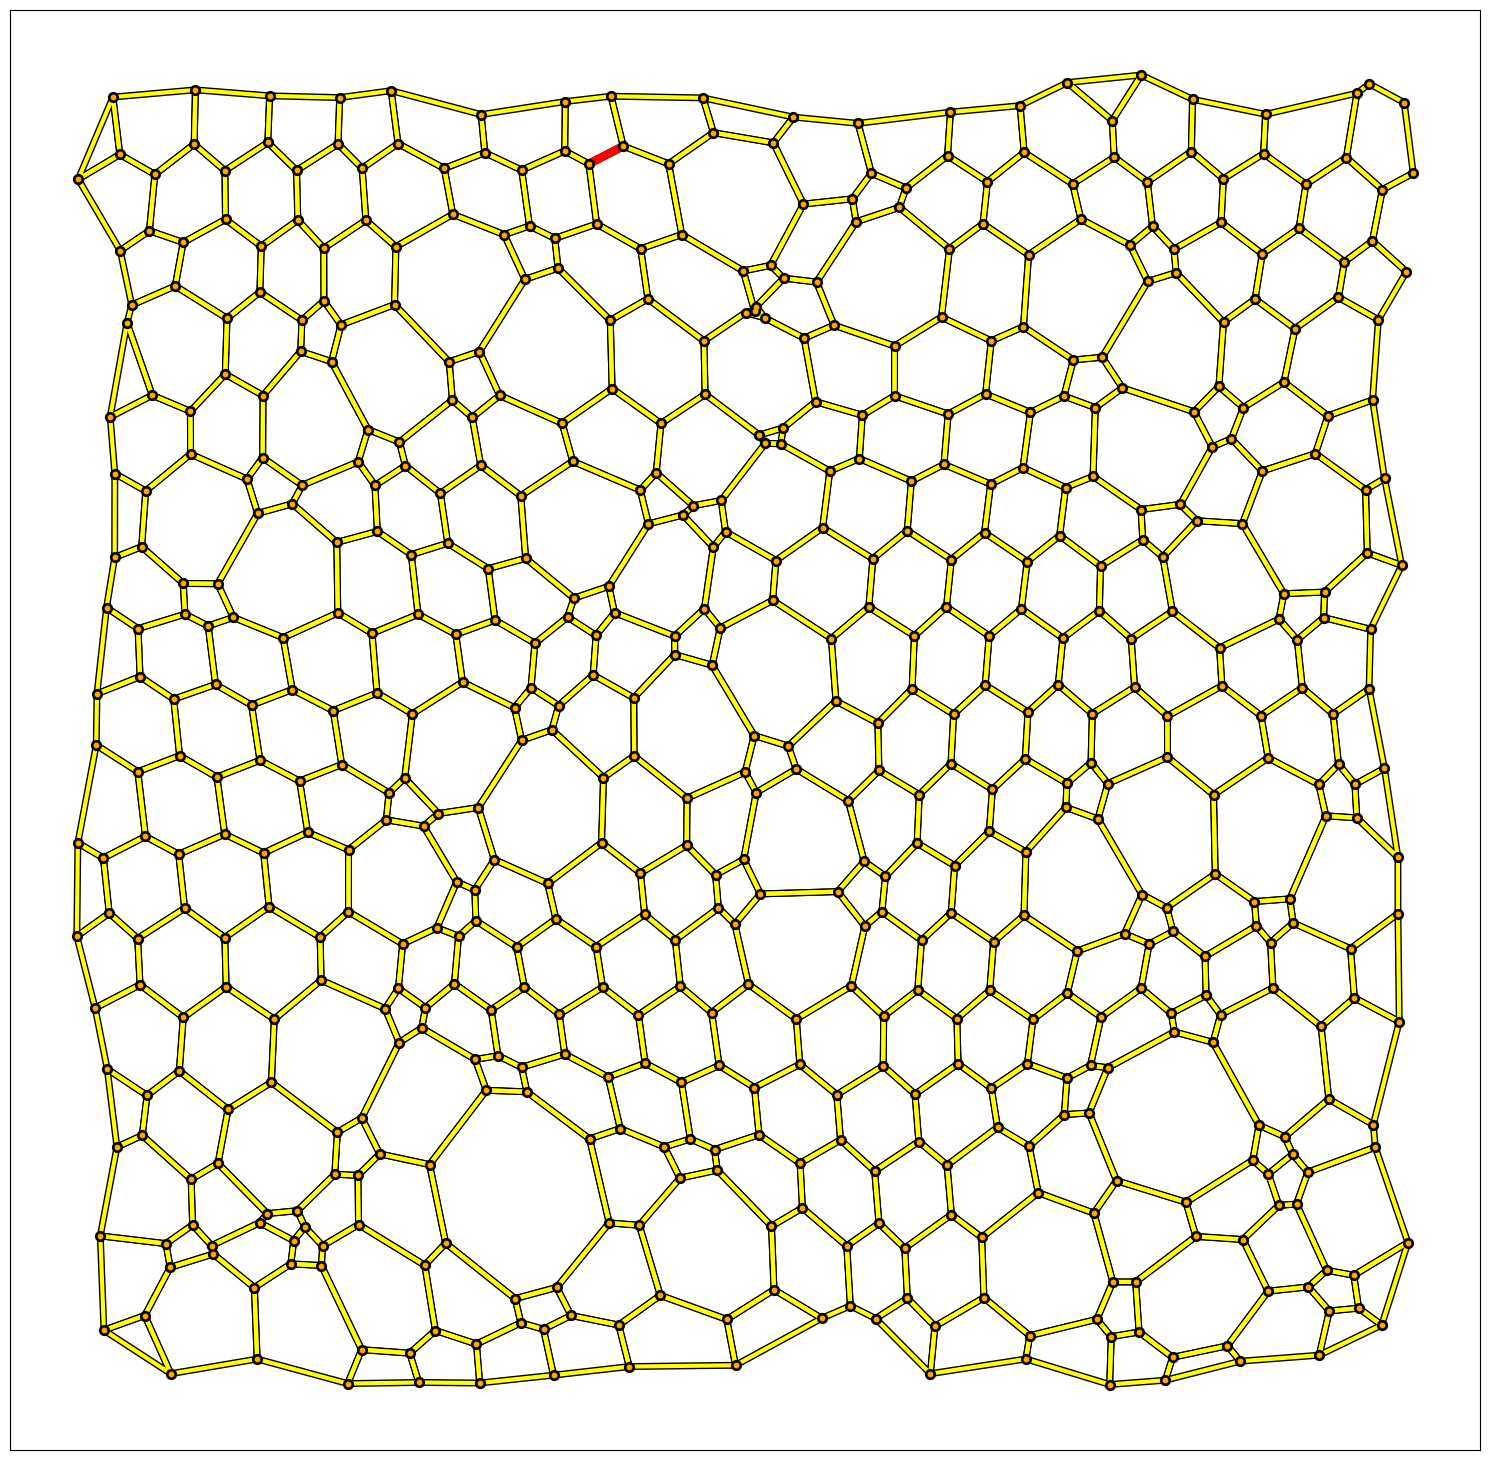

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [144]:
auxFunctions.highlight_edge_on_cellmap(cellmap_init, edge_id=400, figsize=(15, 15),
                              vert_col='orange', edge_highlight_col='red',
                              base_edge_col='black', base_vert_col='black', vert_size=50,
                              save_path=None, show_axes=False,
                              xlim=None, ylim=None,
                              plot_vertices=True, show_figure=True)

In [145]:
cellmap, new_vertex_id = collapse_single_edge(cellmap_init, geom, 400)

In [146]:
new_vertex_id

591

In [147]:
cellmap.vert_df


,y,is_active,x,viscosity
vert,,,,
0,18.360133,1.0,2.097807,1000000.0
1,17.611135,1.0,2.188343,1000000.0
2,17.288384,1.0,1.645284,1000000.0
3,15.414970,1.0,2.281771,1000000.0
4,11.877553,1.0,17.382388,1334.0
...,...,...,...,...
587,6.663914,1.0,14.555475,1334.0
588,6.320067,1.0,14.107663,1334.0
589,5.554219,1.0,14.550899,1334.0


(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

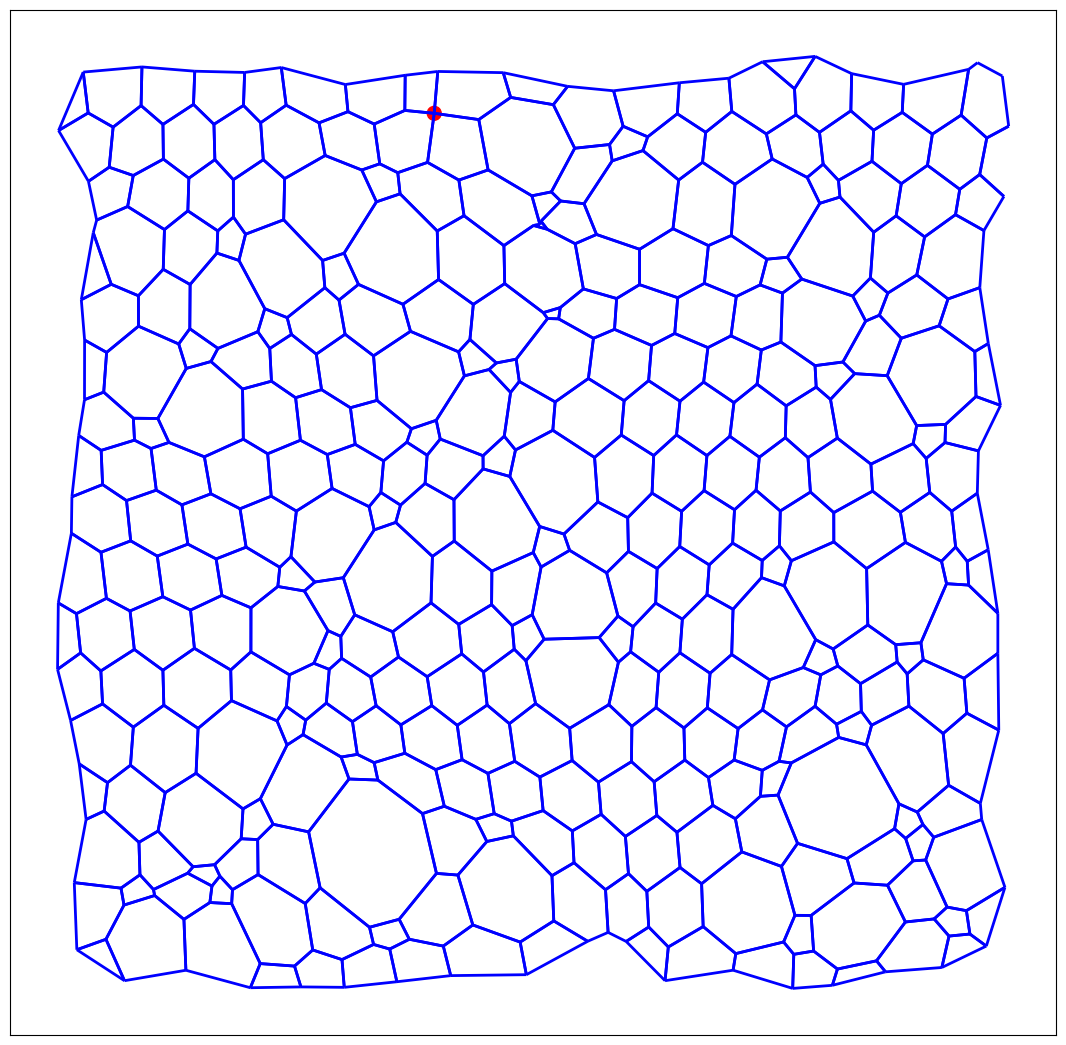

In [148]:
auxFunctions.highlight_vertices(cellmap, geom, [new_vertex_id], default_color='white', highlight_color='red', default_size=50, highlight_size=100)


In [73]:
def split_vertex(cellmap, chosen_vertex, geom, energyContributions_model, distance, retry_attempts=3):
    """
    Safely divide a vertex by creating a nearby new vertex and rewiring edges.
    On failure, rollback and retry up to `retry_attempts` times.

    Returns:
        (cellmap, chosen_vertex, new_vert_index, new_edge_index, opposite_edge_index)
        or (cellmap, chosen_vertex, None, None, None) if all attempts fail.
    """

    original_vert_df = cellmap.vert_df.copy()
    original_edge_df = cellmap.edge_df.copy()

    new_vert_index = None
    new_edge_index = None
    opposite_edge_index = None

    attempt = 0
    while attempt < retry_attempts:
        try:
            # --- Work on temporary copies ---
            temp_vert_df = cellmap.vert_df.copy()
            temp_edge_df = cellmap.edge_df.copy()

            # 1) Find connected edges
            connected_edges = temp_edge_df[
                (temp_edge_df['srce'] == chosen_vertex) |
                (temp_edge_df['trgt'] == chosen_vertex)
            ].copy()

            # 2) Create new vertex nearby
            new_vert_data = temp_vert_df.loc[chosen_vertex].copy()
            angle = np.random.uniform(0, 2*np.pi)
            dx = distance * np.cos(angle)
            dy = distance * np.sin(angle)
            new_vert_data[cellmap.coords] = temp_vert_df.loc[chosen_vertex, cellmap.coords] + [dx, dy]

            new_vert_index = int(temp_vert_df.index.max()) + 1
            temp_vert_df.loc[new_vert_index] = new_vert_data
    
        
            # 3) Create a pair of edges
            # Template: first connected edge (copies all mechanical properties)

            source_edge = connected_edges.iloc[0]

            template = source_edge.copy()

            new_edge_index = int(temp_edge_df.index.max()) + 1
            opposite_edge_index = new_edge_index + 1

            new_edge = template.copy()
            new_edge["srce"], new_edge["trgt"] = chosen_vertex, new_vert_index
            new_edge["face"] = np.nan

            opposite_edge = template.copy()
            opposite_edge["srce"], opposite_edge["trgt"] = new_vert_index, chosen_vertex
            opposite_edge["face"] = np.nan

            temp_edge_df.loc[new_edge_index] = new_edge
            temp_edge_df.loc[opposite_edge_index] = opposite_edge

            # 4) Reassign original edges to closer vertex
            chosen_xy = temp_vert_df.loc[chosen_vertex, cellmap.coords].values.astype(float)
            new_xy    = temp_vert_df.loc[new_vert_index, cellmap.coords].values.astype(float)

            reassigned_edges_to_new_vertex = []
            for e_idx, e in connected_edges.iterrows():
                if e_idx in (new_edge_index, opposite_edge_index):
                    continue
                other = e['trgt'] if e['srce'] == chosen_vertex else e['srce']
                other_xy = temp_vert_df.loc[other, cellmap.coords].values.astype(float)

                d_chosen = np.linalg.norm(other_xy - chosen_xy)
                d_new    = np.linalg.norm(other_xy - new_xy)

                if d_new < d_chosen:
                    reassigned_edges_to_new_vertex.append(e_idx)
                    if e['srce'] == chosen_vertex:
                        temp_edge_df.loc[e_idx, 'srce'] = new_vert_index
                    else:
                        temp_edge_df.loc[e_idx, 'trgt'] = new_vert_index

            # 5) Identify "open" faces (whose edge chains don't close)
            open_faces = []
            for face_id, group in temp_edge_df.groupby('face'):
                verts = list(group[['srce', 'trgt']].itertuples(index=False, name=None))
                if not verts:
                    continue

                # try to follow the loop
                chain = [verts[0][0], verts[0][1]]
                used = {0}
                while True:
                    extended = False
                    for i, (s, t) in enumerate(verts):
                        if i in used:
                            continue
                        if chain[-1] == s:
                            chain.append(t)
                            used.add(i)
                            extended = True
                            break
                        elif chain[-1] == t:
                            chain.append(s)
                            used.add(i)
                            extended = True
                            break
                    if not extended:
                        break

                # if loop doesn't close, this face is "open"
                if chain[0] != chain[-1]:
                    open_faces.append(face_id)

            # filter: only faces touching the new vertex
            open_faces_touching_new = []
            for f in open_faces:
                verts_f = temp_edge_df[temp_edge_df['face'] == f][['srce', 'trgt']].values.ravel()
                if new_vert_index in verts_f or chosen_vertex in verts_f:
                    open_faces_touching_new.append(f)

            print("Open faces touching new vertex:", open_faces_touching_new)

            if len(open_faces_touching_new) != 2:
                raise ValueError(
                    f"Expected 2 open faces, found {len(open_faces_touching_new)}: {open_faces_touching_new}"
                )

            # --- Find which new edge closes which open face ---
            for f in open_faces_touching_new:
                f_edges = temp_edge_df[temp_edge_df['face'] == f]

                # collect src/trgt vertices
                srces = list(f_edges['srce'].astype(int))
                trgts = list(f_edges['trgt'].astype(int))

                # imbalance: start and end
                start_candidates = [v for v in srces if v not in trgts]
                end_candidates   = [v for v in trgts if v not in srces]

                if len(start_candidates) == 1 and len(end_candidates) == 1:
                    start = start_candidates[0]
                    end   = end_candidates[0]
                    needed_edge = (end, start)  # must go end→start to close loop

                    new_pair      = (int(temp_edge_df.loc[new_edge_index, 'srce']),
                                     int(temp_edge_df.loc[new_edge_index, 'trgt']))
                    opposite_pair = (int(temp_edge_df.loc[opposite_edge_index, 'srce']),
                                     int(temp_edge_df.loc[opposite_edge_index, 'trgt']))

                    if new_pair == needed_edge:
                        temp_edge_df.loc[new_edge_index, 'face'] = f
                    elif opposite_pair == needed_edge:
                        temp_edge_df.loc[opposite_edge_index, 'face'] = f
                    else:
                        print(f"Face {f}: expected {needed_edge}, "
                              f"but new={new_pair}, opp={opposite_pair}")
                        
            # --- 6) Verify both assigned faces are closed directed cycles; if not, swap once and recheck

            def _face_closes(df, face_id):
                sub = df[df['face'] == face_id][['srce', 'trgt']]
                # in==out at every vertex
                outc = sub['srce'].value_counts()
                inc  = sub['trgt'].value_counts()
                verts = set(outc.index) | set(inc.index)
                for v in verts:
                    if outc.get(v, 0) != inc.get(v, 0):
                        return False
                # follow edges as a walk using srce->trgt
                start = int(sub.iloc[0]['srce'])
                cur = start
                used = set()
                for _ in range(len(sub)):
                    nxt = sub[~sub.index.isin(used) & (sub['srce'] == cur)]
                    if nxt.empty:
                        return False
                    eidx = nxt.index[0]
                    used.add(eidx)
                    cur = int(sub.loc[eidx, 'trgt'])
                return cur == start and len(used) == len(sub)

            face_new = int(temp_edge_df.loc[new_edge_index, 'face'])
            face_opp = int(temp_edge_df.loc[opposite_edge_index, 'face'])

            ok_new = _face_closes(temp_edge_df, face_new)
            ok_opp = _face_closes(temp_edge_df, face_opp)

            if not (ok_new and ok_opp):
                # try swapping faces between the two new edges once
                temp_edge_df.loc[new_edge_index, 'face'], temp_edge_df.loc[opposite_edge_index, 'face'] = face_opp, face_new
                face_new, face_opp = face_opp, face_new
                ok_new = _face_closes(temp_edge_df, face_new)
                ok_opp = _face_closes(temp_edge_df, face_opp)

            if not (ok_new and ok_opp):
                raise ValueError(
                    f"Face closure failed after assignment: "
                    f"new→face {face_new} ok={ok_new}, opp→face {face_opp} ok={ok_opp}"
            )

            # 7) Commit temp results ---
            cellmap.vert_df = temp_vert_df
            cellmap.edge_df = temp_edge_df

            # Update geometry
            geom.update_all(cellmap)
            cellmap.reset_topo()
            cellmap.reset_index()

            print(f" Successfully divided vertex {chosen_vertex} → new vertex {new_vert_index}")
            return cellmap, chosen_vertex, new_vert_index, new_edge_index, opposite_edge_index

        except Exception as e:
            print(f" split_vertex attempt {attempt+1}/{retry_attempts} failed: {e}")
            # rollback original state
            cellmap.vert_df = original_vert_df.copy()
            cellmap.edge_df = original_edge_df.copy()
            geom.update_all(cellmap)
            cellmap.reset_topo()
            cellmap.reset_index()
            attempt += 1

    print("Failed to divide after multiple attempts.")
    return cellmap, chosen_vertex, None, None, None


In [74]:
def find_vertex_by_edge_sum(cellmap, vertex_list=None, mode='max'):
    """
    Identify a vertex based on the total length of its attached edges.

    Parameters
    ----------
    cellmap : object
        The cellmap containing vertex and edge data.
    vertex_list : list, optional
        List of vertex indices to consider. If None, all vertices are considered.
        Any vertex IDs not present in vert_df are automatically filtered out.
    mode : str, optional
        Selection criterion: 'min' for smallest total edge length,
        'max' for largest total edge length. Default is 'max'.

    Returns
    -------
    int or None
        Index of the selected vertex, or None if no valid vertices found.
    """
    # Determine which vertices to check
    if vertex_list is None:
        vertices_to_check = cellmap.vert_df.index.tolist()
    else:
        # Filter out any vertex IDs that no longer exist
        vertices_to_check = [v for v in vertex_list if v in cellmap.vert_df.index]
    
    if not vertices_to_check:
        return None
    
    chosen_vertex = None
    best_value = -float('inf') if mode == 'max' else float('inf')
    
    for vertex_id in vertices_to_check:
        # Find all edges connected to this vertex
        connected_edges = cellmap.edge_df[
            (cellmap.edge_df['srce'] == vertex_id) | (cellmap.edge_df['trgt'] == vertex_id)
        ]
        
        total_length = connected_edges['length'].sum() if not connected_edges.empty else 0.0
        
        if mode == 'max':
            if total_length > best_value:
                best_value = total_length
                chosen_vertex = vertex_id
        else:  # mode == 'min'
            if total_length < best_value:
                best_value = total_length
                chosen_vertex = vertex_id
    
    return chosen_vertex

In [75]:
# Initialize cellmap, geometry, and energy contributions model
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(10)
cellmap_init = MechanicalParams2.update(cellmap_init)

boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap_init, 1)

#Change outside vertices mechanics
high_viscosity_value = 1000000  # A very large viscosity value
for vertex_id in outside_vertices:
    if vertex_id in cellmap_init.vert_df.index:
        cellmap_init.vert_df.at[vertex_id, "viscosity"] = high_viscosity_value

        
#energyContributions_model.compute_energy(cellmap)
energyContributions_model.compute_energy(cellmap_init)
[cellmap_init, geom, energyContributions_model, history_new, solver1] = vertexModel2.solveEuler(cellmap_init, geom, energyContributions_model, 200)


Topology changed!


(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

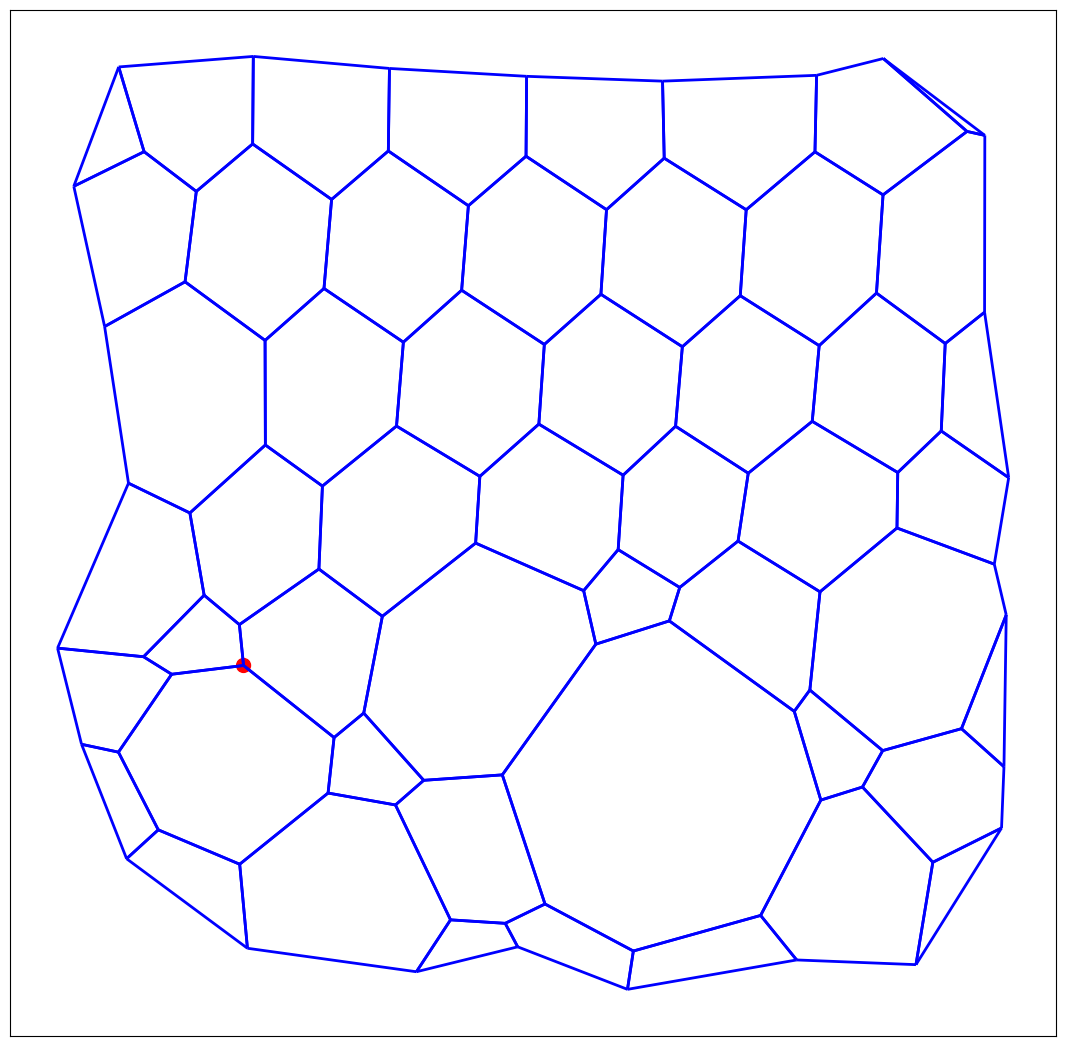

In [76]:
auxFunctions.highlight_vertices(cellmap_init, geom, [chosen_vertex], default_color='white', highlight_color='red', default_size=50, highlight_size=100)


In [77]:
chosen_vertex = find_vertex_by_edge_sum(cellmap_init, vertex_list=None, mode='max')


In [158]:
def homeostasis_simulation(
    energyContributions_model,
    output_folder,
    geom,
    max_cycles,
    max_layers,
    distance,
    collapse_edge_mode: str = "random",
    divide_vertex_mode: str = "max",
):
    """
    Execute a homeostasis simulation alternating edge collapse and vertex division.
    """
    # Create output directory if it does not exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Initialise tissue and mechanical parameters
    cellmap, geom, energyContributions_model = vertexModel2.initialize(10)
    cellmap = MechanicalParams2.update(cellmap)

    # Immobilise boundary vertices by assigning very high viscosity
    boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = auxFunctions.identify_boundary_layers(cellmap, 1)
    high_viscosity = sys.float_info.max
    for vertex_id in outside_vertices:
        if vertex_id in cellmap.vert_df.index:
            cellmap.vert_df.at[vertex_id, "viscosity"] = high_viscosity

    # Initial mechanical relaxation
    energyContributions_model.compute_energy(cellmap)
    cellmap, geom, _, _, _ = vertexModel2.solveEuler(
        cellmap, geom, energyContributions_model, endTime=100
    )

    # Save initial configuration frame
    fig, axes = auxFunctions.view(cellmap, geom)
    fig.savefig(os.path.join(output_folder, "cycle_0_initial_frame.png"), dpi=150)
    plt.close(fig)

    # Main simulation loop
    for cycle_index in range(max_cycles):
        print(f"Processing cycle {cycle_index + 1} of {max_cycles}")

        # Identify interior features (excluding boundary layers)
        boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = (
            auxFunctions.identify_boundary_layers(cellmap, max_layers)
        )

        if not inside_edges or not inside_vertices:
            print("No interior edges or vertices available. Terminating simulation.")
            break

        # -------------------- Edge collapse --------------------
        if collapse_edge_mode == "random":
            chosen_edge = random.choice(inside_edges)
        elif collapse_edge_mode == "min":
            edge_lengths = cellmap.edge_df.loc[inside_edges, "length"]
            chosen_edge = edge_lengths.idxmin()
        elif collapse_edge_mode == "max":
            edge_lengths = cellmap.edge_df.loc[inside_edges, "length"]
            chosen_edge = edge_lengths.idxmax()
        else:
            raise ValueError("collapse_edge_mode must be 'random', 'min', or 'max'")

        print(f"Collapsing edge {chosen_edge} (mode: {collapse_edge_mode})")

        # Execute edge collapse
        cellmap, new_vertex_from_collapse = collapse_single_edge(cellmap, geom, chosen_edge)

        # Save post-collapse visualisation 
        fig, axes = auxFunctions.highlight_vertices(
            cellmap, geom, [new_vertex_from_collapse],
            default_color="white", highlight_color="red",
            default_size=5, highlight_size=100
        )
     
        fig.savefig(
            os.path.join(output_folder, f"cycle_{cycle_index + 1}_collapse_frame.png"),
            dpi=150, bbox_inches="tight"
        )
        plt.close(fig)

        # Reset indices AFTER saving (only once)
        cellmap.reset_index()

        # Mechanical relaxation after collapse
        geom.update_all(cellmap)
        energyContributions_model.compute_energy(cellmap)
        cellmap, geom, _, _, _ = vertexModel2.solveEuler(
            cellmap, geom, energyContributions_model, endTime=40
        )

        # Re-identify interior features after topology change
        boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = (
            auxFunctions.identify_boundary_layers(cellmap, max_layers)
        )

        if not inside_vertices:
            print("No interior vertices available for division. Terminating simulation.")
            break

        # -------------------- Vertex division --------------------
        if divide_vertex_mode == "random":
            chosen_vertex = random.choice(inside_vertices)
        elif divide_vertex_mode == "min":
            chosen_vertex = find_vertex_by_edge_sum(cellmap, vertex_list=inside_vertices, mode='min')
        elif divide_vertex_mode == "max":
            chosen_vertex = find_vertex_by_edge_sum(cellmap, vertex_list=inside_vertices, mode='max')
        else:
            raise ValueError("divide_vertex_mode must be 'random', 'min', or 'max'")

        print(f"Dividing vertex {chosen_vertex} (mode: {divide_vertex_mode})")

        # Execute vertex division
        cellmap, chosen_vertex, new_vertex_index, new_edge_index, opposite_edge_index = split_vertex(
            cellmap, chosen_vertex, geom, energyContributions_model, distance, retry_attempts=3
        )

        # Save post-division visualisation
        if new_vertex_index is not None and new_vertex_index in cellmap.vert_df.index:
            fig, axes = auxFunctions.highlight_vertices(
                cellmap, geom, [new_vertex_index],
                default_color="white", highlight_color="red",
                default_size=5, highlight_size=100
            )
        else:
            fig, axes = auxFunctions.view(cellmap, geom)

        fig.savefig(
            os.path.join(output_folder, f"cycle_{cycle_index + 1}_division_frame.png"),
            dpi=150, bbox_inches="tight"
        )
        plt.close(fig)

        # Reset indices AFTER saving
        cellmap.reset_index()

        # Mechanical relaxation after division
        geom.update_all(cellmap)
        energyContributions_model.compute_energy(cellmap)
        cellmap, geom, _, _, _ = vertexModel2.solveEuler(
            cellmap, geom, energyContributions_model, endTime=40
        )

        print(f"Completed cycle {cycle_index + 1}")

    # Save final state
    auxFunctions.save_simulation_state(cellmap, output_folder, filename="end_cellmap_state.pkl")
    print(f"Simulation finished after {cycle_index + 1} cycles.")

    return cellmap

In [162]:
cellmap = homeostasis_simulation(
    energyContributions_model,
    '2D-lymph-node-vertex-model/test',
    geom,
    5,
    1,
    0.1,
    "random",
    "max",
)

Topology changed!
Processing cycle 1 of 5
Collapsing edge 91 (mode: random)
Topology changed!
Dividing vertex 75.0 (mode: max)
Open faces touching new vertex: [16.0, 17.0]
 Successfully divided vertex 75.0 → new vertex 97
Topology changed!
Completed cycle 1
Processing cycle 2 of 5
Collapsing edge 217 (mode: random)
Topology changed!
Dividing vertex 96.0 (mode: max)
Open faces touching new vertex: [38.0, 44.0]
 Successfully divided vertex 96.0 → new vertex 97
Topology changed!
Completed cycle 2
Processing cycle 3 of 5
Collapsing edge 93 (mode: random)
Topology changed!
Dividing vertex 64.0 (mode: max)
Open faces touching new vertex: [17.0, 19.0]
 Successfully divided vertex 64.0 → new vertex 97
Topology changed!
Completed cycle 3
Processing cycle 4 of 5
Collapsing edge 92 (mode: random)
Topology changed!
Dividing vertex 15.0 (mode: max)
Open faces touching new vertex: [20.0, 27.0]
 Successfully divided vertex 15.0 → new vertex 97
Topology changed!
Completed cycle 4
Processing cycle 5 of

In [161]:
pwd

'/home/veronika/Documents'